In [ ]:
# !pip install pyvirtualdisplay imageio matplotlib -q

In [20]:
# pyvirtualdisplay 없이 바로 렌더링
import gymnasium as gym
import highway_env

env = gym.make('merge-v0', render_mode='rgb_array')
print(env.observation_space.shape)
print(env.action_space.n)
obs, _ = env.reset()
frame = env.render()  # 화면 없이 numpy array로 반환
print(frame.shape)    # (H, W, 3) 이면 성공

(5, 5)
5
(150, 600, 3)


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


In [21]:
# 셀 1 - pyvirtualdisplay 제거, 환경변수만 설정
import sys
import os

sys.path.insert(0, '/mnt/hdd/hyeonseo/workspace/dreamerv3')

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

os.environ['JAX_PLATFORMS'] = 'cuda'
os.environ['LD_LIBRARY_PATH'] = (
    '/mnt/hdd/hyeonseo/.conda/envs/dreamerv3/lib/python3.11/'
    'site-packages/nvidia/cublas/lib:'
    '/mnt/hdd/hyeonseo/.conda/envs/dreamerv3/lib/python3.11/'
    'site-packages/nvidia/cusolver/lib:'
    '/mnt/hdd/hyeonseo/.conda/envs/dreamerv3/lib/python3.11/'
    'site-packages/nvidia/cusparse/lib:'
    '/mnt/hdd/hyeonseo/.conda/envs/dreamerv3/lib/python3.11/'
    'site-packages/nvidia/cufft/lib:'
    '/mnt/hdd/hyeonseo/.conda/envs/dreamerv3/lib/python3.11/'
    'site-packages/nvidia/cudnn/lib:'
    '/mnt/hdd/hyeonseo/.conda/envs/dreamerv3/lib'
)

import jax
print('JAX devices:', jax.devices())

JAX devices: [cuda(id=0)]


In [ ]:
# 셀 2 - 환경 + 에이전트 로드
import gymnasium as gym
import highway_env
import numpy as np
import imageio
import pathlib
import elements
import ruamel.yaml as yaml
from dreamerv3.agent import Agent

# config 로드
folder = pathlib.Path('/mnt/hdd/hyeonseo/workspace/dreamerv3/dreamerv3')
configs = yaml.YAML(typ='safe').load(
    (folder / 'configs.yaml').read_text())
config = elements.Config(configs['defaults'])
for name in ['highway', 'size12m']:
    config = config.update(configs[name])
config = config.update(logdir='/mnt/hdd/hyeonseo/workspace/dreamerv3/logdir/highway_merge')

# 에이전트 초기화
obs_space = {
    "obs": elements.Space(np.float32, (5, 5)),
    "reward": elements.Space(np.float32),
    "is_first": elements.Space(bool),
    "is_last": elements.Space(bool),
    "is_terminal": elements.Space(bool),
}
act_space = {"action": elements.Space(np.int32, (), 0, 5)}

agent = Agent(obs_space, act_space, elements.Config(
    **config.agent,
    logdir=config.logdir,
    seed=config.seed,
    jax=config.jax,
    batch_size=config.batch_size,
    batch_length=config.batch_length,
    replay_context=config.replay_context,
    report_length=config.report_length,
    replica=config.replica,
    replicas=config.replicas,
))

# 체크포인트 로드 부분 수정 - load_or_save 대신 load만 사용
cp = elements.Checkpoint(pathlib.Path(config.logdir) / 'ckpt')
cp.agent = agent

# 체크포인트 존재 확인
ckpt_dir = pathlib.Path(config.logdir) / 'ckpt'
print("ckpt 폴더 내용:")
for f in ckpt_dir.iterdir():
    print(f)

# load만 실행 (save 안 함)
cp.load()
print("체크포인트 로드 완료!")

Observations
  obs              Space(float32, shape=(15, 7), low=-inf, high=inf)
  reward           Space(float32, shape=(), low=-inf, high=inf)
  is_first         Space(bool, shape=(), low=False, high=True)
  is_last          Space(bool, shape=(), low=False, high=True)
  is_terminal      Space(bool, shape=(), low=False, high=True)
Actions
  action           Space(int32, shape=(), low=0, high=3)
Extras
  consec           Space(int32, shape=(), low=-2147483648, high=2147483647)
  stepid           Space(uint8, shape=(20,), low=0, high=255)
  dyn/deter        Space(float32, shape=(2048,), low=-inf, high=inf)
  dyn/stoch        Space(float32, shape=(32, 16), low=-inf, high=inf)
JAX devices (1): [cuda:0]
Policy devices: cuda:0
Train devices:  cuda:0
Initializing parameters...
Optimizer opt has 9,776,491 params:
     5,782,272 dyn
       853,503 val
       814,953 dec
       788,739 pol
       721,407 rew
       656,129 con
       159,488 enc
Done initializing!
Compiling 1 checkpoint groups

In [18]:
# 셀 3 - 추론 + GIF 저장
env = gym.make('intersection-v0', render_mode='rgb_array',config={"duration": 300})
frames = []
obs_raw, _ = env.reset()
done = False
total_reward = 0
carry = agent.init_policy(1)
is_first = True

while not done:
    frame = env.render()
    frames.append(frame)

    obs = {
        "obs": np.array([obs_raw], dtype=np.float32),        # (1, 5, 5)
        "reward": np.array([0.0], dtype=np.float32),          # (1,)
        "is_first": np.array([is_first]),                     # (1,)
        "is_last": np.array([False]),                         # (1,)
        "is_terminal": np.array([False]),                     # (1,)
    }
    is_first = False

    carry, act, _ = agent.policy(carry, obs, mode='eval')
    action = int(act['action'][0])
    obs_raw, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    done = terminated or truncated

env.close()
print(f"총 점수: {total_reward:.2f}, 프레임 수: {len(frames)}")

imageio.mimsave('highway_intersection_inference.gif', frames, fps=10)
print("GIF 저장 완료!")

ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


총 점수: 10.00, 프레임 수: 10
GIF 저장 완료!


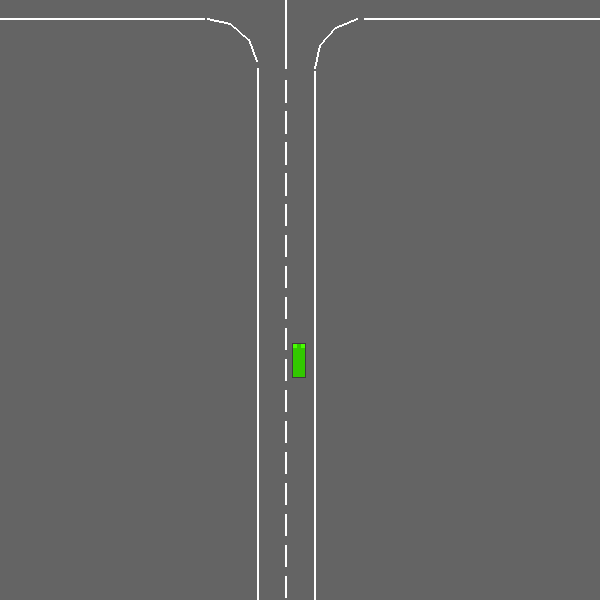

In [19]:
# 셀 4 - 노트북에서 바로 보기
from IPython.display import Image
Image('highway_intersection_inference.gif')